## Processing Observations
The objective of this code is to process the raw data from Hydrographic Bottles of the CCHDO (CLIVAR and Carbon Hydrographic Data Office (CCHDO)) Project. The variables used are Silicate, Nitrate, Phosphate, Oxygen, Temeprature, and Chlorophyll_a, more variables can added in the first lines. 

The code starts by fetching it from Diego's thesis folder, which only contains transects that crossed the 30°S line. The first filter of the data is the WOCE flags, which are basically quality flags that the researches put at the moment of analysis.This data is then saved in a new data frame that also contains other data such as the front in which the measurement happened. Then, the data frame is updated with an iterative outlier removal is then used as in described in Freeman et al (2019), reducing the number of observations. The last two cells generates outputs with the data, the first one plots the number of observations per season and variable, and the last cell plots the seasonal cycle, using a centered mean.

In [1]:
## Importing Libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy import stats
import os

import warnings
warnings.filterwarnings("ignore")

In [ ]:
folder_path = "/glade/u/home/diegovar/tesis/NShipData/"

bottles = []

for filename in os.listdir(folder_path):
    if filename.endswith("_bottle.nc"):
        file_path = os.path.join(folder_path, filename)
        bottles.append(file_path)

variables = {
    "silicate":        "silicate",
    "nitrate":         "nitrate",
    "nitrite":         "nitrite",
    "phosphate":       "phosphate",
    "oxygen":          "oxygen",
    "temperature":     "ctd_temperature",
    "salinity":        "ctd_salinity",
    'chlorophyll_a': 'chlorophyll_a',
}


In [ ]:
def isSouthOcean(filepath):
    n = np.size(bottles)
    boolarray = []
    idx = []
    Dates = []
    for x in range(n):
        array = xr.open_dataset(filepath[x])
        latitudes = array['latitude'].values
        latmin = np.min(latitudes)
        bool = latmin <= -60
        boolarray.append(bool)

        if bool == True:
            idx.append(x)
            DateStart = array['time'][0].values
            DateEnd = array['time'][-1].values
            dateint = [DateStart, DateEnd]
            Dates.append(dateint)
            
    return idx, Dates

def isSouth30(filepath):
    n = np.size(bottles)
    boolarray = []
    idx = []
    Dates = []
    for x in range(n):
        array = xr.open_dataset(filepath[x])
        latitudes = array['latitude'].values
        latmax = np.max(latitudes)
        latmin = np.min(latitudes)
        bool = latmin <= -31
        boolarray.append(bool)

        if bool == True:
            idx.append(x)
            DateStart = array['time'][0].values
            DateEnd = array['time'][-1].values
            dateint = [DateStart, DateEnd]
            Dates.append(dateint)
            
    return idx, Dates

print('Number of Bottles ', np.size(bottles))
BottlesIndexSO, DatesSO  = isSouthOcean(bottles)
BottlesIndexS30, DatesS30  = isSouth30(bottles)
print('Number of Bottles that cross the Southern Ocean', np.size(BottlesIndexSO))
print('Number of Bottles that cross 30°S', np.size(BottlesIndexS30))

np.save('BottlesIndexS30.npy', BottlesIndexS30)    
np.save('DatesS30.npy', DatesS30)   

Number of Bottles  209
Number of Bottles that cross the Southern Ocean 117
Number of Bottles that cross 30°S 209


In [6]:
BottlesIndex = np.load('BottlesIndexS30.npy')
Dates = np.load('DatesS30.npy')

# ---- helpers ----
def season_from_month(m):
    if m in (12, 1, 2):
        return "DJF"
    elif m in (3, 4, 5):
        return "MAM"
    elif m in (6, 7, 8):
        return "JJA"
    else:
        return "SON"


In [7]:
np.size(BottlesIndex)

209

## Filtering 

In [ ]:
# ============================================================
# QC FLAG FILTERING
# WOCE Bottle flags: 2 = acceptable, 6 = mean of replicates
# WOCE CTD flags:    2 = acceptable, 6 = interpolated
# ============================================================

# Map each data variable to its QC flag variable and acceptable flag values
QC_FLAGS = {
    # Bottle measurements (WOCEBOTTLE)
    "silicate":   ("silicate_qc",        [2, 6]),
    "nitrate":    ("nitrate_qc",         [2, 6]),
    "nitrite":    ("nitrite_qc",         [2, 6]),
    "phosphate":  ("phosphate_qc",       [2, 6]),
    "oxygen":     ("oxygen_qc",          [2, 6]),
    
    # CTD measurements (WOCECTD)
    "ctd_temperature": (None, [2, 6]),
    "ctd_salinity":    ("ctd_salinity_qc",    [2, 6]),
    'chlorophyll_a': ('chlorophyll_qc', [2, 6])
}

def apply_qc(ds, varname):
    """
    Return a QC-masked array for varname in dataset ds.
    If QC_FLAGS entry is None, all finite values are accepted as-is.
    Returns None if the variable is not present in the dataset.
    """
    if varname not in ds:
        return None

    data = ds[varname].values.astype(float)

    qc_entry = QC_FLAGS.get(varname, None)

    # No QC defined or explicitly set to None — accept all finite values
    if qc_entry is None:
        return data

    qc_varname, good_flags = qc_entry

    if qc_varname not in ds:
        #print(f"  WARNING: {qc_varname} not found in dataset, skipping QC for {varname}")
        return data

    qc = ds[qc_varname].values.astype(float)
    bad_mask  = ~np.isin(qc, good_flags)
    bad_mask |= ~np.isfinite(qc)
    data[bad_mask] = np.nan

    return data


def get_surface_value(data_2d, profile_idx, max_levels=10):
    """
    Extract a representative near-surface value for one profile.
    Takes the median of the top `max_levels` finite values.
    Adjust max_levels based on your vertical resolution.
    """
    profile = data_2d[profile_idx, :max_levels]
    finite_vals = profile[np.isfinite(profile)]
    if len(finite_vals) == 0:
        return np.nan
    return float(np.nanmedian(finite_vals))


# ============================================================
# Quick QC diagnostic — how many values survive per variable?
# Run this BEFORE building your main dataframe to check data loss
# ============================================================

def qc_diagnostic(bottles, BottlesIndex, QC_FLAGS, sample_n=10):
    """
    For the first `sample_n` files, print how many values survive QC
    per variable. Useful sanity check before full pipeline.
    """
    print("=== QC Diagnostic (first {} files) ===".format(sample_n))
    total   = defaultdict(int)
    kept    = defaultdict(int)

    for i in BottlesIndex[:sample_n]:
        ds = xr.open_dataset(bottles[i])
        for varname, (qc_var, good_flags) in QC_FLAGS.items():
            if varname not in ds:
                continue
            data = ds[varname].values.astype(float)
            total[varname] += np.isfinite(data).sum()
            masked = apply_qc(ds, varname)
            kept[varname]  += np.isfinite(masked).sum()
        ds.close()

    print(f"{'Variable':<20} {'Total finite':>14} {'After QC':>10} {'% kept':>8}")
    print("-" * 56)
    for v in total:
        t = total[v]
        k = kept[v]
        pct = 100 * k / t if t > 0 else 0
        print(f"{v:<20} {t:>14,} {k:>10,} {pct:>7.1f}%")


# Run diagnostic first
qc_diagnostic(bottles, BottlesIndex, QC_FLAGS, sample_n=10)

=== QC Diagnostic (first 10 files) ===
Variable               Total finite   After QC   % kept
--------------------------------------------------------
silicate                     13,948     12,816    91.9%
nitrate                      11,239      9,951    88.5%
oxygen                       14,176     13,556    95.6%
ctd_temperature              15,693     15,693   100.0%
ctd_salinity                 15,657     15,360    98.1%
chlorophyll_a                   293        293   100.0%
nitrite                      10,264      9,206    89.7%
phosphate                    13,544     12,152    89.7%


In [10]:
Lat = np.arange(-90, 90, 1)   # shape (180,)
Lon = np.arange(-180, 180, 1) # shape (360,)

# zone_masks[zone] is True where the zone is ABSENT (nan → True).
# A point is IN a zone when mask is False (i.e., the zone grid is non-nan there).
zone_order = ["siz", "az", "pfz", "saz", "stz"]

def assign_zone(lat_val, lon_val):
    """Return the frontal zone name for a single (lat, lon) point."""
    lat_idx = np.argmin(np.abs(Lat - lat_val))
    lon_val_wrapped = ((lon_val + 180) % 360) - 180   # ensure -180 to 180
    lon_idx = np.argmin(np.abs(Lon - lon_val_wrapped))
    for zone in zone_order:
        if not zone_masks[zone][lat_idx, lon_idx]:    # False = point is IN zone
            return zone
    return "outside"

zones = {
    "siz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/siz_grid.npy'),
    "az": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/az_grid.npy'),
    "saz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/saz_grid.npy'),
    "stz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/stz_grid.npy'),
    "pfz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/pfz_grid.npy')}

print("Loaded")

for key in zones:
    zones[key] = zones[key].astype(float)
    zones[key] = np.where(zones[key] == 0, np.nan, zones[key])

siz_zone = zones['siz']
az_zone = zones['az']
saz_zone = zones['saz']
stz_zone = zones['stz']
pfz_zone = zones['pfz']

print(siz_zone.shape)
# masked_ds = ds.where(nmask) 
#boolian values -. True (1) or False (0) 
#SIZ ZONE MASK
mask_siz = np.isnan(np.flipud(siz_zone)) #sends nan values to True, non nans to False
#AZ ZONE MASK
mask_az = np.isnan(np.flipud(az_zone)) #sends nan values to True, non nans to False
#SAZ ZONE MASK
mask_saz = np.isnan(np.flipud(saz_zone)) #sends nan values to True, non nans to False
#STZ ZONE MASK
mask_stz = np.isnan(np.flipud(stz_zone)) #sends nan values to True, non nans to False
#PFZ ZONE MASK
mask_pfz = np.isnan(np.flipud(pfz_zone))  #sends nan values to True, non nans to False


zone_masks = {
    "siz": mask_siz,
    "az": mask_az,
    "pfz": mask_pfz,
    "saz": mask_saz,
    "stz": mask_stz,
    
}

print(mask_pfz)

regions = ['siz', 'az','pfz', 'saz', 'stz']

zone_masks = {
    "siz": mask_siz,
    "az": mask_az,
    "pfz": mask_pfz,
    "saz": mask_saz,
    "stz": mask_stz,
}
region_colors = {
    "siz": "blue",
    "az": "green",
    "pfz": "yellow",
    "saz": "orange",
    "stz": "red",
}


Loaded
(180, 360)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [11]:
# ============================================================
# UPDATED STEP 2: Build dataframe with QC applied
# ============================================================

records = []


for i in BottlesIndex:
    ds = xr.open_dataset(bottles[i])
    times = ds["time"].values
    lats  = ds["latitude"].values
    lons  = ds["longitude"].values
    nprof = ds.dims["N_PROF"]

    # Apply QC to all variables once per file (not per profile)
    qc_data = {}
    
    for label, varname in variables.items():
        qc_data[label] = apply_qc(ds, varname)   # None if var absent

    for p in range(nprof):
        t      = times[p]
        lat    = float(lats[p])
        lon    = float(lons[p])
        year   = int(str(t)[:4])
        month  = int(str(t)[5:7])
        season = season_from_month(month)
        zone   = assign_zone(lat, lon)

        row = {
            "year": year, "month": month, "season": season,
            "lat": lat, "lon": lon, "zone": zone,
        }

        for label in variables:
            if qc_data[label] is None:
                row[label] = np.nan
            else:
                row[label] = get_surface_value(qc_data[label], p)

        records.append(row)

    ds.close()

df = pd.DataFrame(records)
print(f"\nTotal profiles loaded: {len(df)}")

print("\nProfiles per zone:")
print(df["zone"].value_counts())

print("\nFinite values per variable after QC:")
print(df[list(variables.keys())].notna().sum())


Total profiles loaded: 17552

Profiles per zone:
zone
outside    5507
siz        4630
stz        3717
pfz        1314
az         1306
saz        1078
Name: count, dtype: int64

Finite values per variable after QC:
silicate         14011
nitrate          11822
nitrite           8706
phosphate        13413
oxygen           14894
temperature      15436
salinity         15504
chlorophyll_a      372
dtype: int64


In [12]:
df

,year,month,season,lat,lon,zone,silicate,nitrate,nitrite,phosphate,oxygen,temperature,salinity,chlorophyll_a
0,2000,7,JJA,-30.0000,54.1000,outside,1.80,0.100,NaN,NaN,228.10,20.140,35.8700,0.110
1,2000,7,JJA,-28.0000,55.0000,outside,2.02,0.010,NaN,NaN,249.20,20.810,35.7700,0.085
2,2000,7,JJA,-34.9800,53.5200,stz,2.30,0.400,NaN,NaN,238.10,17.755,35.7220,0.255
3,2000,7,JJA,-40.0000,52.8200,stz,3.20,2.800,NaN,NaN,231.10,16.540,35.5830,0.270
4,2000,7,JJA,-47.6700,58.0000,pfz,6.15,21.200,NaN,NaN,304.80,5.360,33.7510,-4.345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17547,1987,12,DJF,-34.1817,114.2417,stz,5.05,17.300,0.0,1.240,235.60,NaN,34.5740,NaN
17548,1987,12,DJF,-34.1700,114.4100,stz,3.26,11.140,0.0,0.865,229.20,NaN,34.9045,NaN
17549,1987,12,DJF,-34.1617,114.5050,stz,2.25,0.635,0.0,0.180,227.25,NaN,35.7850,NaN
17550,1987,12,DJF,-34.1717,114.7467,stz,2.05,0.000,0.0,0.160,234.00,NaN,35.8330,NaN


In [12]:
df = df[df['zone']!='outside']

=== Outlier Removal Summary ===
variable  nitrate  oxygen  phosphate  salinity  silicate  temperature
zone                                                                 
az           0.00    0.00       0.00      0.00      0.00         0.17
outside      0.00    0.00       0.00      0.07      3.09         0.00
pfz          0.22    0.00       0.00      0.09      2.15         0.52
saz          0.00    0.82       0.00      0.42      4.40         0.00
siz          0.75    0.00       0.97      0.12      0.00         0.00
stz          0.04    2.23       0.43      0.00      7.07         0.00


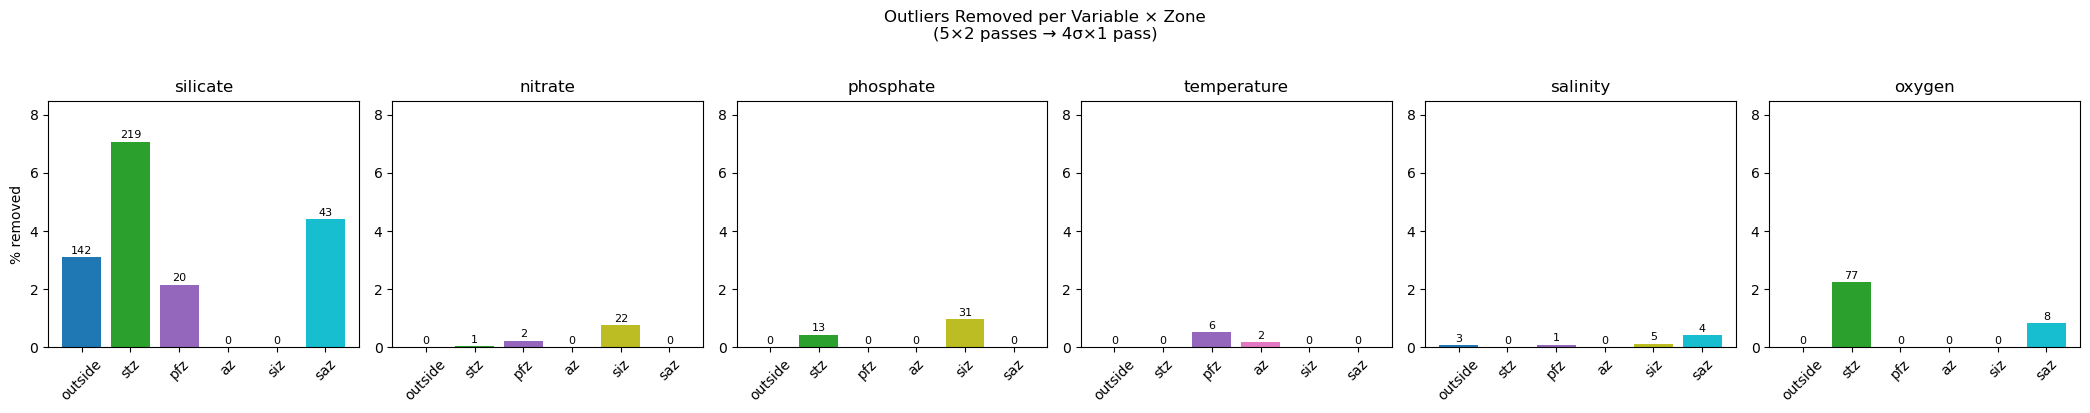

In [13]:
# ============================================================
# OUTLIER REMOVAL
# Iterative sigma-clipping per variable × zone
# Pass 1: remove > 4σ (twice)
# Pass 2: remove > 3σ
# Mirrors Freeman et al. (2019) iterative QC approach
# ============================================================

def sigma_clip(series, n_sigma, max_iter=1):
    """
    Iteratively remove values beyond n_sigma standard deviations.
    Repeats up to max_iter times or until no new outliers are found.
    Returns a boolean mask: True = keep, False = outlier.
    """
    mask = np.ones(len(series), dtype=bool)   # start: keep everything
    
    for iteration in range(max_iter):
        vals = series[mask]
        if len(vals) < 3:
            break
        mu  = vals.mean()
        sig = vals.std()
        if sig == 0:
            break
        new_mask = mask.copy()
        new_mask[mask] = np.abs(vals - mu) <= n_sigma * sig
        
        n_removed = mask.sum() - new_mask.sum()
        if n_removed == 0:
            break                             # converged, stop early
        mask = new_mask

    return mask


def iterative_outlier_removal(df, varlist, zone_col="zone"):
    """
    Apply iterative sigma-clipping to each variable × zone combination.

    Pipeline (mirrors Freeman et al.):
      Step 1a: 4σ clip, up to 2 iterations
      Step 1b: 4σ clip, up to 2 iterations  (second pass at 4σ)
      Step 2:  3σ clip, up to 2 iterations

    Values flagged as outliers are set to NaN in-place.
    Returns the cleaned dataframe and a diagnostic summary.
    """
    df_clean = df.copy()
    diagnostics = []

    zones = df_clean[zone_col].unique()

    for var in varlist:
        if var not in df_clean.columns:
            continue

        for zone in zones:
            zone_mask = df_clean[zone_col] == zone
            finite_mask = zone_mask & df_clean[var].notna()
            idx = df_clean.index[finite_mask]

            if len(idx) < 10:          # too few points to clip meaningfully
                continue

            values = df_clean.loc[idx, var].values
            n_start = len(values)

            # --- Pass 1: 4σ twice ---
            keep = sigma_clip(values, n_sigma=5, max_iter=2)
            values_after_4sig = values.copy()
            values_after_4sig[~keep] = np.nan

            # --- Pass 2: 4σ twice again (second application) ---
            keep2 = sigma_clip(values_after_4sig[keep], n_sigma=5, max_iter=2)
            surviving_idx = idx[keep]
            surviving_idx2 = surviving_idx[keep2]

            # --- Pass 3: 3σ ---
            values_after_4sig2 = df_clean.loc[surviving_idx2, var].values
            keep3 = sigma_clip(values_after_4sig2, n_sigma=4, max_iter=2)
            final_idx = surviving_idx2[keep3]

            # Build full outlier index and NaN them out
            all_outlier_idx = idx.difference(final_idx)
            df_clean.loc[all_outlier_idx, var] = np.nan

            n_removed = len(all_outlier_idx)
            diagnostics.append({
                "variable": var,
                "zone":     zone,
                "n_start":  n_start,
                "n_removed": n_removed,
                "n_final":  n_start - n_removed,
                "pct_removed": 100 * n_removed / n_start if n_start > 0 else 0,
            })

    diag_df = pd.DataFrame(diagnostics)
    return df_clean, diag_df


# ============================================================
# OUTLIER DIAGNOSTIC PLOT
# Shows how many points were removed per variable × zone
# ============================================================

def plot_outlier_diagnostics(diag_df):
    varlist   = diag_df["variable"].unique()
    zone_list = diag_df["zone"].unique()

    fig, axes = plt.subplots(1, len(varlist),
                             figsize=(3.5 * len(varlist), 4),
                             sharey=False)
    if len(varlist) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, len(zone_list)))

    for ax, var in zip(axes, varlist):
        sub = diag_df[diag_df["variable"] == var]
        bars = ax.bar(sub["zone"], sub["pct_removed"],
                      color=colors[:len(sub)])
        ax.set_title(var)
        ax.set_ylabel("% removed" if ax == axes[0] else "")
        ax.set_ylim(0, max(diag_df["pct_removed"].max() * 1.2, 1))
        ax.tick_params(axis='x', rotation=45)

        # Annotate bar with absolute count
        for bar, (_, row) in zip(bars, sub.iterrows()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    str(int(row["n_removed"])),
                    ha='center', va='bottom', fontsize=8)

    plt.suptitle("Outliers Removed per Variable × Zone\n"
                 "(5×2 passes → 4σ×1 pass)", y=1.02)
    plt.tight_layout()
    plt.savefig("ActualFig/OutlierDiagnostics.png", dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# USAGE — run after building df and assigning zones
# ============================================================

varlist_to_clip = ["silicate", "nitrate", "phosphate",
                   "temperature", "salinity", "oxygen"]

df_clean, diag_df = iterative_outlier_removal(df, varlist_to_clip)

# Review summary table
print("=== Outlier Removal Summary ===")
print(diag_df.pivot_table(
    index="zone", columns="variable",
    values="pct_removed", aggfunc="sum"
).round(2).to_string())

# Visual check
plot_outlier_diagnostics(diag_df)

# Replace df with cleaned version for all downstream analysis
df = df_clean

In [14]:
# ============================================================
# SAVE PREPROCESSED DATAFRAME
# Run once after QC + outlier removal — skip preprocessing 
# on all subsequent runs by loading from file instead
# ============================================================

import os

SAVE_PATH = "preprocessed_bottles.parquet"

def save_preprocessed(df, path=SAVE_PATH):
    """
    Save cleaned dataframe to parquet format.
    Parquet is preferred over CSV for this use case:
      - preserves dtypes (float32, categorical, datetime)
      - ~5-10x smaller file size than CSV
      - much faster read/write than CSV or pickle
    """
    df.to_parquet(path, index=True)
    size_mb = os.path.getsize(path) / 1e6
    print(f"Saved to {path}  ({size_mb:.1f} MB, {len(df):,} rows)")


# 1. Build records with QC applied
records = []
for i in BottlesIndex:
    ds = xr.open_dataset(bottles[i])
    times = ds["time"].values
    lats  = ds["latitude"].values
    lons  = ds["longitude"].values
    nprof = ds.dims["N_PROF"]

    qc_data = {}
    for label, varname in variables.items():
        qc_data[label] = apply_qc(ds, varname)

    for p in range(nprof):
        t      = times[p]
        lat    = float(lats[p])
        lon    = float(lons[p])
        year   = int(str(t)[:4])
        month  = int(str(t)[5:7])
        season = season_from_month(month)
        zone   = assign_zone(lat, lon)

        row = {
            "year": year, "month": month, "season": season,
            "lat": lat, "lon": lon, "zone": zone,
        }
        for label in variables:
            if qc_data[label] is None:
                row[label] = np.nan
            else:
                row[label] = get_surface_value(qc_data[label], p)

        records.append(row)
    ds.close()

df = pd.DataFrame(records)

df = df[df['zone']!='outside']

# 2. Outlier removal
varlist_to_clip = ["silicate", "nitrate", "phosphate",
                   "temperature", "salinity", "oxygen"]
df, diag_df = iterative_outlier_removal(df, varlist_to_clip)

# 3. Save so we never have to do this again
save_preprocessed(df, SAVE_PATH)

Saved to preprocessed_bottles.parquet  (0.5 MB, 12,045 rows)


In [15]:
df = pd.read_parquet("preprocessed_bottles.parquet")

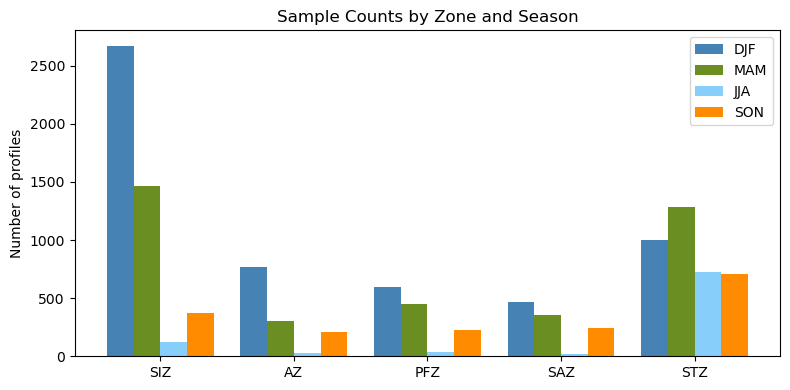


===== SEASONAL AMPLITUDES (cold - warm) =====

SIZ:
  silicate    : +1.85
  nitrate     : -0.24
  temperature : -0.53

AZ:
  silicate    : -1.15
  nitrate     : +0.43
  temperature : -1.17

PFZ:
  silicate    : -0.35
  nitrate     : -0.49
  temperature : -0.66

SAZ:
  silicate    : +0.78
  nitrate     : +0.93
  temperature : -1.00

STZ:
  silicate    : -0.72
  nitrate     : -1.02
  temperature : +0.53


In [ ]:
# ============================================================
# STEP 4: SAMPLE COUNTS per zone × season (like Freeman Fig. 2)
# ============================================================

count_table = df.groupby(["zone", "season"]).size().unstack(fill_value=0)
count_table = count_table.reindex(index=zone_order, columns=season_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(zone_order))
width = 0.2
season_colors = {"DJF": "steelblue", "MAM": "olivedrab",
                 "JJA": "lightskyblue", "SON": "darkorange"}

for k, s in enumerate(season_order):
    ax.bar(x + k * width, count_table[s], width,
           label=s, color=season_colors[s])
    
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([zone_labels[z] for z in zone_order])
ax.set_ylabel("Number of profiles")
ax.set_title("Sample Counts by Zone and Season")
ax.legend()
plt.tight_layout()
plt.savefig("SampleCounts_byZone.png", dpi=300)
plt.show()


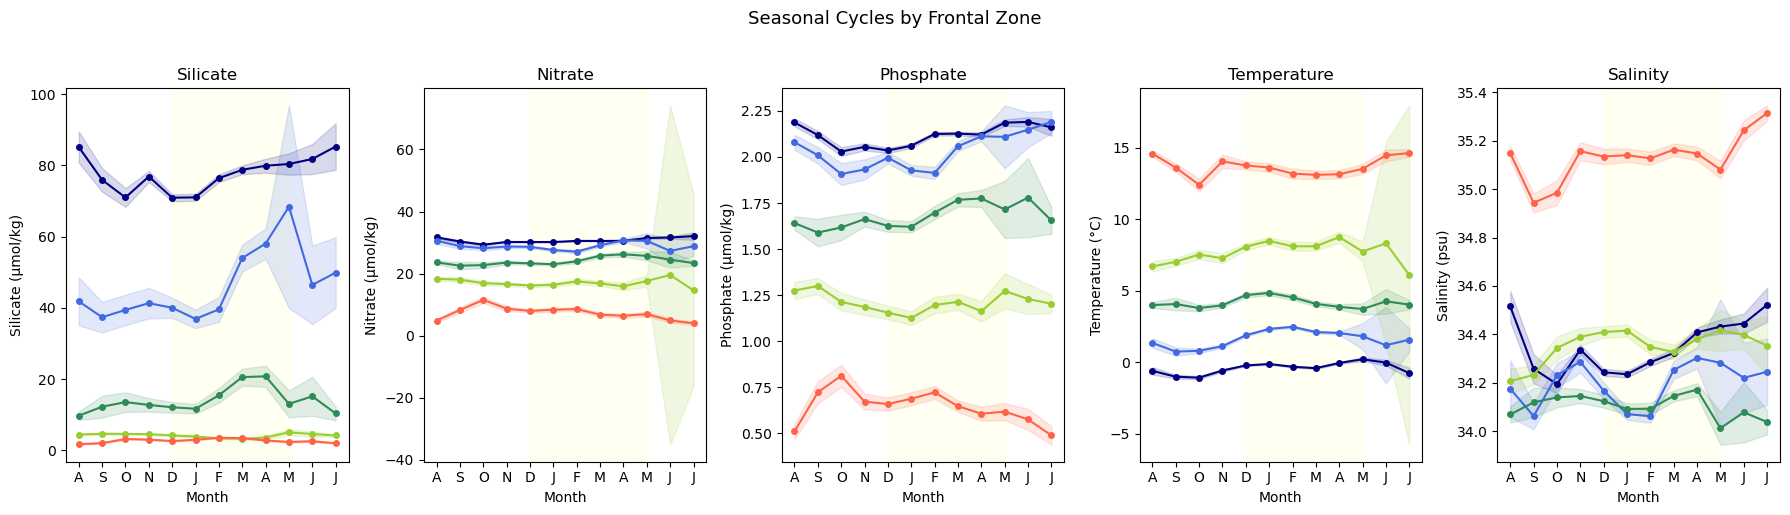

In [17]:
# ============================================================
# STEP 4: SEASONAL CYCLES — 3-month means + 95% CI per zone
# Emulates Freeman et al. Figure 4
# ============================================================

def ci95(vals):
    """95% CI using Z (n>=30) or t distribution (n<30)."""
    n = len(vals)
    if n < 2:
        return np.nan
    se = stats.sem(vals, nan_policy='omit')
    return 1.96 * se if n >= 30 else stats.t.ppf(0.975, df=n-1) * se

# 3-month rolling window centered on each month
def three_month_mean(df_zone, varname):
    """Returns dict: month → (mean, ci, n) using ±1 month window."""
    result = {}
    for center in range(1, 13):
        months_in = [(center - 1) % 12 + 1,
                     center,
                     (center % 12) + 1]
        sub = df_zone[df_zone["month"].isin(months_in)][varname].dropna()
        if len(sub) > 0:
            result[center] = (sub.mean(), ci95(sub.values), len(sub))
        else:
            result[center] = (np.nan, np.nan, 0)
    return result

# Seasonal amplitude: max(JJASON) - max(DJFMAM) for nutrients (opposite for temp)
def seasonal_amplitude(df_zone, varname):
    warm = df_zone[df_zone["season"].isin(["DJF", "MAM"])][varname].dropna()
    cold = df_zone[df_zone["season"].isin(["JJA", "SON"])][varname].dropna()
    if len(warm) == 0 or len(cold) == 0:
        return np.nan
    return cold.mean() - warm.mean()  # positive = higher in winter (nutrients)

# ============================================================
# STEP 5: PLOT — Seasonal cycles (Figure 4 equivalent)
# ============================================================

zone_colors = {
    "siz": "navy", "az": "royalblue",
    "pfz": "seagreen", "saz": "yellowgreen", "stz": "tomato"
}
zone_labels = {
    "siz": "SIZ", "az": "AZ", "pfz": "PFZ", "saz": "SAZ", "stz": "STZ"
}

plot_vars = ["silicate", "nitrate", "phosphate", "temperature", "salinity"]
ylabels   = ["Silicate (μmol/kg)", "Nitrate (μmol/kg)", "Phosphate (μmol/kg)",
             "Temperature (°C)", "Salinity (psu)"]

# Month order: Aug → Jul (like Freeman)
month_order = [8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7]
month_labels = ["A","S","O","N","D","J","F","M","A","M","J","J"]

fig, axes = plt.subplots(1, len(plot_vars), figsize=(18, 5), sharey=False)

for ax, varname, ylabel in zip(axes, plot_vars, ylabels):
    for zone in zone_order:
        sub  = df[df["zone"] == zone]
        cyc  = three_month_mean(sub, varname)
        amp  = seasonal_amplitude(sub, varname)

        means = np.array([cyc[m][0] for m in month_order])
        cis   = np.array([cyc[m][1] for m in month_order])

        x = np.arange(len(month_order))
        ax.plot(x, means, 'o-', color=zone_colors[zone],
                label=f"{zone_labels[zone]} ({amp:+.1f})", markersize=4)
        ax.fill_between(x, means - cis, means + cis,
                        color=zone_colors[zone], alpha=0.15)

    ax.set_xticks(range(len(month_order)))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.set_title(varname.capitalize())
    #ax.legend(fontsize=7, title="Zone (amp)")
    # Shade warm season (D,J,F,M,A,M = indices 4-9 in month_order)
    ax.axvspan(4, 9, color="lightyellow", alpha=0.4, zorder=0)

plt.suptitle("Seasonal Cycles by Frontal Zone", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("ActualFig/SeasonalCycles_byZone.png", dpi=300, bbox_inches="tight")
plt.show()